# 05 - EDA Avancada: STJ Integras com Matplotlib

**Objetivo:** Analise exploratoria completa em perspectiva de data scientist senior.

Cobrir: volume temporal, composicao documental, ministros, origem processual (CNJ), assuntos enriquecidos, tempos processuais, qualidade de dados e insights.

## 1. Setup

In [18]:
import json
import re
import sys
from pathlib import Path
from collections import Counter
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

print('Imports loaded.')

Imports loaded.


In [19]:
def find_project_root(start: Path) -> Path:
    """Localiza a raiz do projeto a partir do cwd do kernel."""
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'notebooks').exists() and (candidate / 'data').exists():
            return candidate
        if candidate.name == 'datajud_probe':
            return candidate
    return start

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

PROJECT_ROOT = find_project_root(Path.cwd())

if IN_COLAB:
    MOUNT_POINT = Path('/content/drive')
    if (MOUNT_POINT / 'MyDrive').exists():
        print('Google Drive ja esta montado.')
    else:
        drive.mount(str(MOUNT_POINT), force_remount=True)
    DATA_ROOT = MOUNT_POINT / 'MyDrive/Mestrado/2026/llms/data'
else:
    DATA_ROOT = PROJECT_ROOT / 'data'

METADATA_RAW = DATA_ROOT / 'raw' / 'stj_integras_metadata'
REPORTS_DATA = DATA_ROOT / 'reports' / 'summaries'
FIGURES_DATA = DATA_ROOT / 'reports' / 'figures'
REFERENCE_DATA = DATA_ROOT / 'reference'

for path in [REPORTS_DATA, FIGURES_DATA, REFERENCE_DATA]:
    path.mkdir(parents=True, exist_ok=True)

# ==========================================================================
# PARAMETRIZACAO DO RECORTE TEMPORAL
# --------------------------------------------------------------------------
# Defina ANOS_ANALISE para filtrar por subpastas de ano em METADATA_RAW.
#   - None              -> carrega TODOS os anos disponiveis
#   - [2024]            -> apenas 2024
#   - [2023, 2024]      -> 2023 e 2024
#   - list(range(2022, 2027)) -> 2022 ate 2026
# ==========================================================================
ANOS_ANALISE = [2026]  # <-- Altere aqui, sem commitar outputs do recorte exploratorio

if not METADATA_RAW.exists():
    raise FileNotFoundError(
        f'Diretorio de metadados nao encontrado: {METADATA_RAW}. '
        'Rode o notebook 00 ou ajuste DATA_ROOT.'
    )

anos_disponiveis = sorted(
    int(p.name) for p in METADATA_RAW.iterdir()
    if p.is_dir() and p.name.isdigit() and len(p.name) == 4
)

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'DATA_ROOT: {DATA_ROOT}')
print(f'METADATA_RAW: {METADATA_RAW}')
print(f'REPORTS_DATA: {REPORTS_DATA}')
print(f'FIGURES_DATA: {FIGURES_DATA}')
print(f'Anos disponiveis em disco: {anos_disponiveis}')
print(f'ANOS_ANALISE: {list(ANOS_ANALISE) if ANOS_ANALISE else "todos"}')

Google Drive ja esta montado.
PROJECT_ROOT: /content
DATA_ROOT: /content/drive/MyDrive/Mestrado/2026/llms/data
METADATA_RAW: /content/drive/MyDrive/Mestrado/2026/llms/data/raw/stj_integras_metadata
REPORTS_DATA: /content/drive/MyDrive/Mestrado/2026/llms/data/reports/summaries
FIGURES_DATA: /content/drive/MyDrive/Mestrado/2026/llms/data/reports/figures
Anos disponiveis em disco: [2023, 2024, 2025, 2026]
ANOS_ANALISE: [2026]


In [20]:
from IPython.display import display

plt.style.use('default')
plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 160,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

THOUSANDS = mticker.FuncFormatter(lambda value, _: f'{value:,.0f}'.replace(',', '.'))

def show_fig(fig, name: str | None = None):
    """Exibe figura Matplotlib inline e salva PNG quando nomeada."""
    fig.tight_layout()
    if name:
        output_path = FIGURES_DATA / f'{name}.png'
        fig.savefig(output_path, bbox_inches='tight')
    display(fig)
    plt.close(fig)

def plot_barh(series: pd.Series, title: str, xlabel: str, name: str, color: str = '#2E86AB'):
    data = series.dropna().sort_values()
    fig, ax = plt.subplots(figsize=(10, max(4, len(data) * 0.35)))
    ax.barh(data.index.astype(str), data.values, color=color)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.xaxis.set_major_formatter(THOUSANDS)
    ax.grid(axis='x', alpha=0.25)
    ax.grid(axis='y', visible=False)
    show_fig(fig, name)

def plot_table(df: pd.DataFrame, max_rows: int = 20):
    display(df.head(max_rows))

print('Helpers loaded (Matplotlib inline).')

Helpers loaded (Matplotlib inline).


## 2. Carregamento Consolidado dos Metadados

In [21]:
def metadata_sort_key(path: Path) -> str:
    match = re.fullmatch(r'metadados(\d{6}|\d{8})\.json', path.name)
    return match.group(1) if match else path.name

# Filtrar por ANOS_ANALISE ou carregar todos os disponíveis
anos_para_carregar = set(ANOS_ANALISE) if ANOS_ANALISE else set(anos_disponiveis)
anos_ausentes = anos_para_carregar - set(anos_disponiveis)
if anos_ausentes:
    print(f'⚠️  Anos solicitados mas não encontrados em disco: {sorted(anos_ausentes)}')

metadata_files = []
for ano in sorted(anos_para_carregar & set(anos_disponiveis)):
    year_dir = METADATA_RAW / str(ano)
    metadata_files.extend(year_dir.glob('metadados*.json'))

metadata_files = sorted(metadata_files, key=metadata_sort_key)

if not metadata_files:
    raise FileNotFoundError(
        f'Nenhum arquivo metadados*.json encontrado para anos {sorted(anos_para_carregar)} em {METADATA_RAW}'
    )

print(f'Anos carregados: {sorted(anos_para_carregar & set(anos_disponiveis))}')
print(f'Arquivos encontrados: {len(metadata_files)}')
print(f'Intervalo: {metadata_files[0].name} a {metadata_files[-1].name}')

Anos carregados: [2026]
Arquivos encontrados: 71
Intervalo: metadados20260102.json a metadados20260417.json


In [22]:
def load_metadata(path: Path) -> pd.DataFrame:
    with path.open('r', encoding='utf-8') as f:
        data = json.load(f)
    if isinstance(data, list):
        df_file = pd.DataFrame(data)
    elif isinstance(data, dict):
        list_vals = [v for v in data.values() if isinstance(v, list)]
        df_file = pd.DataFrame(list_vals[0]) if len(list_vals) == 1 else pd.json_normalize(data)
    else:
        raise ValueError(f'Formato JSON inesperado: {type(data)}')
    df_file['arquivo_origem'] = path.name
    return df_file

metadata_list = []
for path in metadata_files:
    try:
        metadata_list.append(load_metadata(path))
    except Exception as e:
        print(f'Erro em {path.name}: {e}')

if not metadata_list:
    raise RuntimeError('Nenhum arquivo de metadados foi carregado com sucesso.')

df = pd.concat(metadata_list, ignore_index=True)
print(f'Metadados consolidados: {df.shape[0]:,} linhas x {df.shape[1]:,} colunas')
print(f'Memoria: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')

Metadados consolidados: 193,979 linhas x 13 colunas
Memoria: 157.0 MB


## 3. Qualidade dos Dados

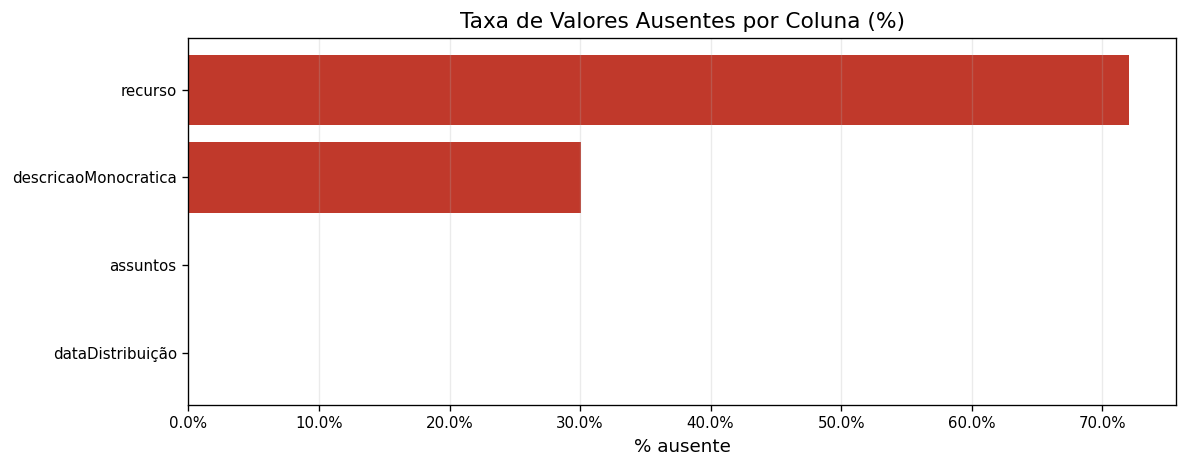

In [23]:
missing_pct = (df.isna().sum() / len(df) * 100).sort_values()
missing_pct = missing_pct[missing_pct > 0]

if missing_pct.empty:
    print('Nao ha valores ausentes nas colunas carregadas.')
else:
    fig, ax = plt.subplots(figsize=(10, max(4, len(missing_pct) * 0.35)))
    ax.barh(missing_pct.index.astype(str), missing_pct.values, color='#C0392B')
    ax.set_title('Taxa de Valores Ausentes por Coluna (%)')
    ax.set_xlabel('% ausente')
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(decimals=1))
    ax.grid(axis='x', alpha=0.25)
    ax.grid(axis='y', visible=False)
    show_fig(fig, '01_taxa_ausentes')

## 4. Evolução Temporal

In [24]:
df['dataPublicacao'] = pd.to_datetime(df.get('dataPublicacao', pd.Series([pd.NaT]*len(df))), errors='coerce')
if 'dataPublicacao' in df.columns and df['dataPublicacao'].notna().any():
    print(f'Intervalo: {df["dataPublicacao"].min()} a {df["dataPublicacao"].max()}')
    df['ano'] = df['dataPublicacao'].dt.year
    df['mes'] = df['dataPublicacao'].dt.month

Intervalo: 2026-01-02 00:00:00 a 2026-04-17 00:00:00


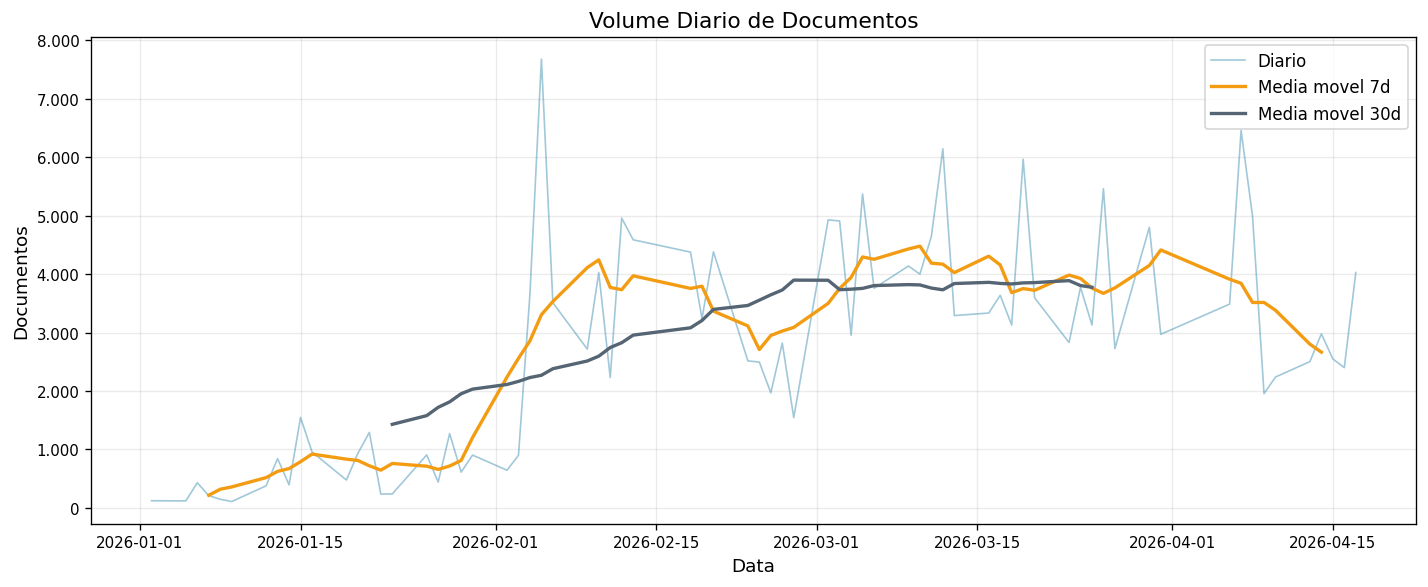

In [25]:
# Volume diario com media movel
if 'dataPublicacao' in df.columns and df['dataPublicacao'].notna().any():
    daily = df.groupby(df['dataPublicacao'].dt.date).size().reset_index(name='documentos')
    daily.columns = ['data', 'documentos']
    daily['data'] = pd.to_datetime(daily['data'])
    daily = daily.sort_values('data')
    daily['ma7'] = daily['documentos'].rolling(7, center=True).mean()
    daily['ma30'] = daily['documentos'].rolling(30, center=True).mean()

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(daily['data'], daily['documentos'], color='#2E86AB', alpha=0.45, linewidth=1, label='Diario')
    ax.plot(daily['data'], daily['ma7'], color='#F39C12', linewidth=2, label='Media movel 7d')
    if daily['ma30'].notna().any():
        ax.plot(daily['data'], daily['ma30'], color='#566573', linewidth=2, label='Media movel 30d')
    ax.set_title('Volume Diario de Documentos')
    ax.set_xlabel('Data')
    ax.set_ylabel('Documentos')
    ax.yaxis.set_major_formatter(THOUSANDS)
    ax.legend()
    ax.grid(alpha=0.25)
    show_fig(fig, '02_volume_diario')
else:
    print('Sem dataPublicacao valida para grafico temporal.')

## 5. Composição Documental

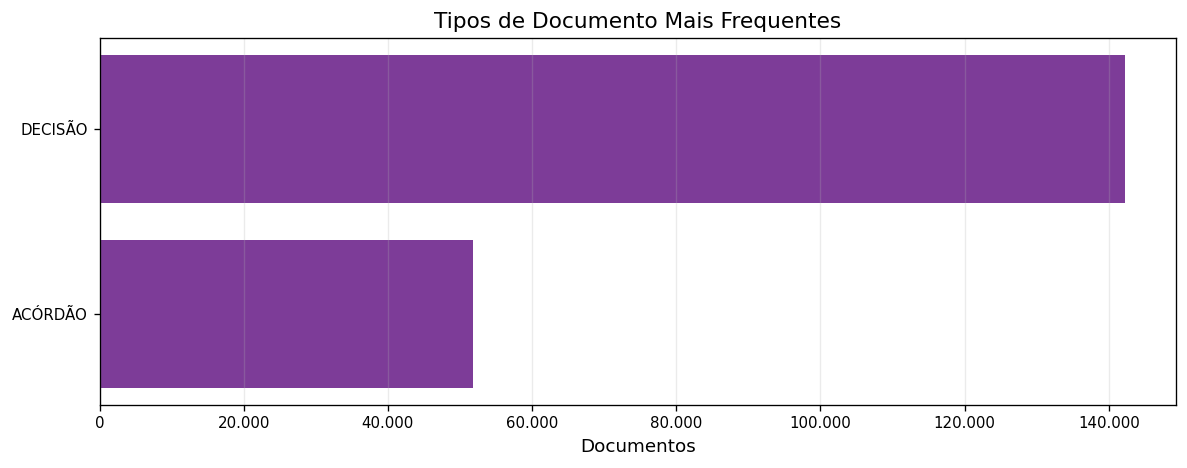

In [26]:
# Tipo de documento
if 'tipoDocumento' in df.columns:
    tipo_counts = df['tipoDocumento'].fillna('(vazio)').value_counts().head(15)
    plot_barh(
        tipo_counts,
        title='Tipos de Documento Mais Frequentes',
        xlabel='Documentos',
        name='03_tipo_documento',
        color='#7D3C98',
    )
else:
    print('Coluna tipoDocumento nao encontrada.')

## 6. Análise de Ministros

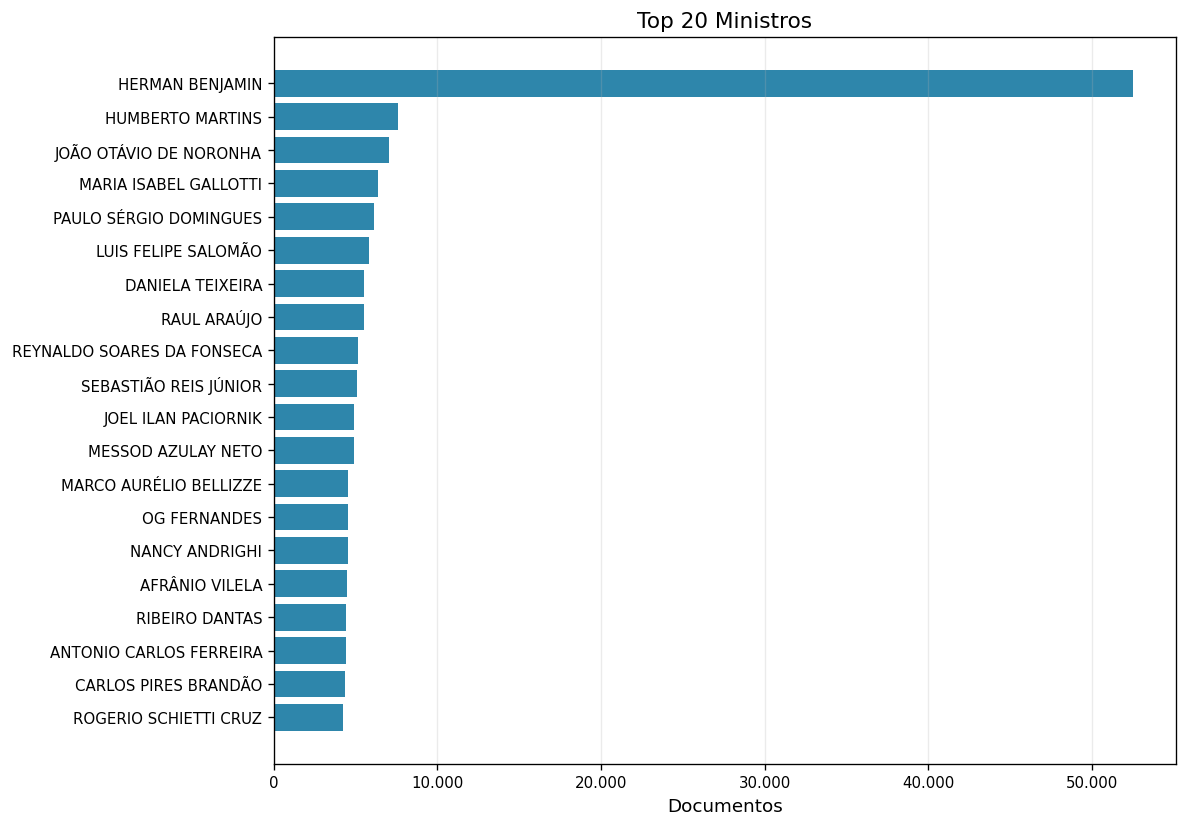

In [27]:
col_ministro = 'ministro' if 'ministro' in df.columns else 'NM_MINISTRO'
if col_ministro in df.columns:
    ministro_counts = df[col_ministro].fillna('(vazio)').value_counts().head(20)
    plot_barh(
        ministro_counts,
        title='Top 20 Ministros',
        xlabel='Documentos',
        name='04_ministros',
        color='#2E86AB',
    )
else:
    print('Coluna de ministro nao encontrada.')

## 7. Processos (CNJ)

In [28]:
def parse_cnj_number(process_str: str) -> dict:
    if pd.isna(process_str):
        return {}
    digits = re.sub(r'\D', '', str(process_str))
    match = re.fullmatch(r'(\d{7})(\d{2})(\d{4})(\d)(\d{2})(\d{4})', digits)
    if not match:
        return {}
    seq, check, year, segment, tribunal, origin = match.groups()
    segments = {
        '1': 'STF',
        '2': 'CNJ',
        '3': 'STJ',
        '4': 'Justica Federal',
        '5': 'Justica do Trabalho',
        '6': 'Justica Eleitoral',
        '7': 'Justica Militar da Uniao',
        '8': 'Justica Estadual',
        '9': 'Justica Militar Estadual',
    }
    return {
        'ano_cnj': int(year),
        'segmento_cnj': segments.get(segment, segment),
        'tribunal_cnj': tribunal,
        'origem_cnj': origin,
    }

PROCESSO_COLUMNS = ['numeroProcesso', 'processo', 'numero_processo', 'processoFormatado']
col_processo = next((col for col in PROCESSO_COLUMNS if col in df.columns), None)

if col_processo:
    cnj_parsed = df[col_processo].apply(parse_cnj_number).apply(pd.Series)
    df = pd.concat([df, cnj_parsed], axis=1)
    parsed_rows = int(cnj_parsed['ano_cnj'].notna().sum()) if 'ano_cnj' in cnj_parsed else 0
    print(f'Coluna de processo: {col_processo}')
    print(f'Processos parseados: {parsed_rows:,} de {len(df):,}')
else:
    print(f'Nenhuma coluna de processo encontrada. Candidatas: {PROCESSO_COLUMNS}')

Coluna de processo: processo
Processos parseados: 0 de 193,979


In [29]:
# Distribuicao por segmento CNJ
if 'segmento_cnj' in df.columns and df['segmento_cnj'].notna().any():
    seg_counts = df['segmento_cnj'].fillna('N/A').value_counts()
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.pie(
        seg_counts.values,
        labels=seg_counts.index.astype(str),
        autopct='%1.1f%%',
        startangle=90,
        counterclock=False,
    )
    ax.set_title('Distribuicao por Segmento CNJ de Origem')
    show_fig(fig, '05_segmento_cnj')
else:
    print('Sem processos CNJ parseados para gerar distribuicao por segmento.')

Sem processos CNJ parseados para gerar distribuicao por segmento.


## 8. Assuntos

In [30]:
def find_assuntos_lookup() -> Path | None:
    candidates = [
        Path('/Users/felipeignacio/Projects/datajud_probe/data/reference/assuntos/processed/assuntos_lookup.parquet'),
        Path('/Users/felipeignacio/Projects/datajud_probe/data/reference/assuntos/processed/assuntos_lookup.csv'),
        PROJECT_ROOT / 'data' / 'reference' / 'assuntos' / 'processed' / 'assuntos_lookup.parquet',
        PROJECT_ROOT / 'data' / 'reference' / 'assuntos' / 'processed' / 'assuntos_lookup.csv',
        DATA_ROOT / 'reference' / 'assuntos' / 'processed' / 'assuntos_lookup.parquet',
        DATA_ROOT / 'reference' / 'assuntos' / 'processed' / 'assuntos_lookup.csv',
        REFERENCE_DATA / 'assuntos' / 'processed' / 'assuntos_lookup.parquet',
        REFERENCE_DATA / 'assuntos' / 'processed' / 'assuntos_lookup.csv',
    ]

    seen = []
    for candidate in candidates:
        candidate = candidate.expanduser().resolve()
        if candidate in seen:
            continue
        seen.append(candidate)
        if candidate.exists():
            return candidate

    search_roots = [
        DATA_ROOT,
        PROJECT_ROOT,
        Path('/content/drive/MyDrive') if IN_COLAB else None,
    ]
    search_roots = [root for root in search_roots if root is not None and root.exists()]
    for root in search_roots:
        for pattern in ['assuntos_lookup.parquet', 'assuntos_lookup.csv']:
            matches = list(root.rglob(pattern))
            if matches:
                found = matches[0].resolve()
                print(f'Lookup encontrado por busca recursiva em {root}: {found}')
                return found

    print('Lookup nao encontrado. Caminhos testados:')
    for candidate in seen:
        print(f'  - {candidate}')
    if IN_COLAB:
        print('Kernel em Colab: caminhos locais /Users/... nao sao acessiveis aqui.')
        print('Copie assuntos_lookup.parquet ou assuntos_lookup.csv para:')
        print(f'  - {DATA_ROOT / "reference" / "assuntos" / "processed"}')
    return None

def find_raw_assuntos_table() -> Path | None:
    candidates = [
        PROJECT_ROOT / 'notebooks' / '78_Tabela_Assuntos_Justica_Federal_1_Grau.xls',
        Path.cwd() / 'notebooks' / '78_Tabela_Assuntos_Justica_Federal_1_Grau.xls',
        Path.cwd() / '78_Tabela_Assuntos_Justica_Federal_1_Grau.xls',
        Path.cwd().parent / 'notebooks' / '78_Tabela_Assuntos_Justica_Federal_1_Grau.xls',
    ]
    for candidate in candidates:
        candidate = candidate.resolve()
        if candidate.exists():
            return candidate
    return None

def load_lookup_from_raw_table(raw_path: Path) -> pd.DataFrame:
    if str(PROJECT_ROOT) not in sys.path:
        sys.path.insert(0, str(PROJECT_ROOT))

    from src.assuntos import add_hierarchy_paths, parse_assuntos_files, save_assuntos_lookup

    print(f'Parseando tabela bruta de assuntos: {raw_path}')
    parsed = parse_assuntos_files([raw_path])
    parsed = add_hierarchy_paths(parsed)

    output_dir = PROJECT_ROOT / 'data' / 'reference' / 'assuntos' / 'processed'
    output_dir.mkdir(parents=True, exist_ok=True)
    outputs = save_assuntos_lookup(parsed, output_dir)
    print('Lookup processado salvo:')
    for name, path in outputs.items():
        print(f'  - {name}: {path}')
    return parsed

ASSUNTOS_LOOKUP_CANDIDATES = [
    Path('/Users/felipeignacio/Projects/datajud_probe/data/reference/assuntos/processed/assuntos_lookup.csv'),
    Path('/Users/felipeignacio/Projects/datajud_probe/data/reference/assuntos/processed/assuntos_lookup.parquet'),
    PROJECT_ROOT / 'data' / 'reference' / 'assuntos' / 'processed' / 'assuntos_lookup.csv',
    PROJECT_ROOT / 'data' / 'reference' / 'assuntos' / 'processed' / 'assuntos_lookup.parquet',
    DATA_ROOT / 'reference' / 'assuntos' / 'processed' / 'assuntos_lookup.csv',
    DATA_ROOT / 'reference' / 'assuntos' / 'processed' / 'assuntos_lookup.parquet',
    REFERENCE_DATA / 'assuntos' / 'processed' / 'assuntos_lookup.csv',
    REFERENCE_DATA / 'assuntos' / 'processed' / 'assuntos_lookup.parquet',
]
lookup_path = find_assuntos_lookup()

if lookup_path is None:
    raw_assuntos_path = find_raw_assuntos_table()
    if raw_assuntos_path is None:
        assuntos_lookup = pd.DataFrame()
        print('Tabela bruta de assuntos tambem nao encontrada.')
    else:
        assuntos_lookup = load_lookup_from_raw_table(raw_assuntos_path)
elif lookup_path.suffix == '.parquet':
    assuntos_lookup = pd.read_parquet(lookup_path)
    print(f'Lookup carregado: {lookup_path} ({len(assuntos_lookup):,} linhas)')
else:
    assuntos_lookup = pd.read_csv(
        lookup_path,
        dtype={'codigo': 'string', 'codigo_pai': 'string'},
    )
    print(f'Lookup carregado: {lookup_path} ({len(assuntos_lookup):,} linhas)')

if not assuntos_lookup.empty:
    print(f'Codigos unicos no lookup: {assuntos_lookup["codigo"].nunique():,}')
    if 'instancia' in assuntos_lookup.columns:
        print('Instancias no lookup:')
        display(assuntos_lookup['instancia'].fillna('(vazio)').value_counts().rename_axis('instancia').reset_index(name='linhas'))

Lookup carregado: /content/drive/MyDrive/Mestrado/2026/llms/data/reference/assuntos/processed/assuntos_lookup.parquet (2,435 linhas)
Codigos unicos no lookup: 2,435
Instancias no lookup:


,instancia,linhas
0,Justiça Federal 1º Grau,2435


Lookup por codigo: 2,435 codigos; nomes divergentes entre instancias: 0
Assuntos com nome no lookup: 1,899 de 2,571 codigos finais.
Top codigos analisados: ['03608', '03372', '10433', '04355', '05897', '05566', '03633', '10439', '09596', '09587']
Codigos top sem match no lookup: ['10496', '04703', '04305', '04993', '10621', '13237', '07687', '10904', '10865', '14227']


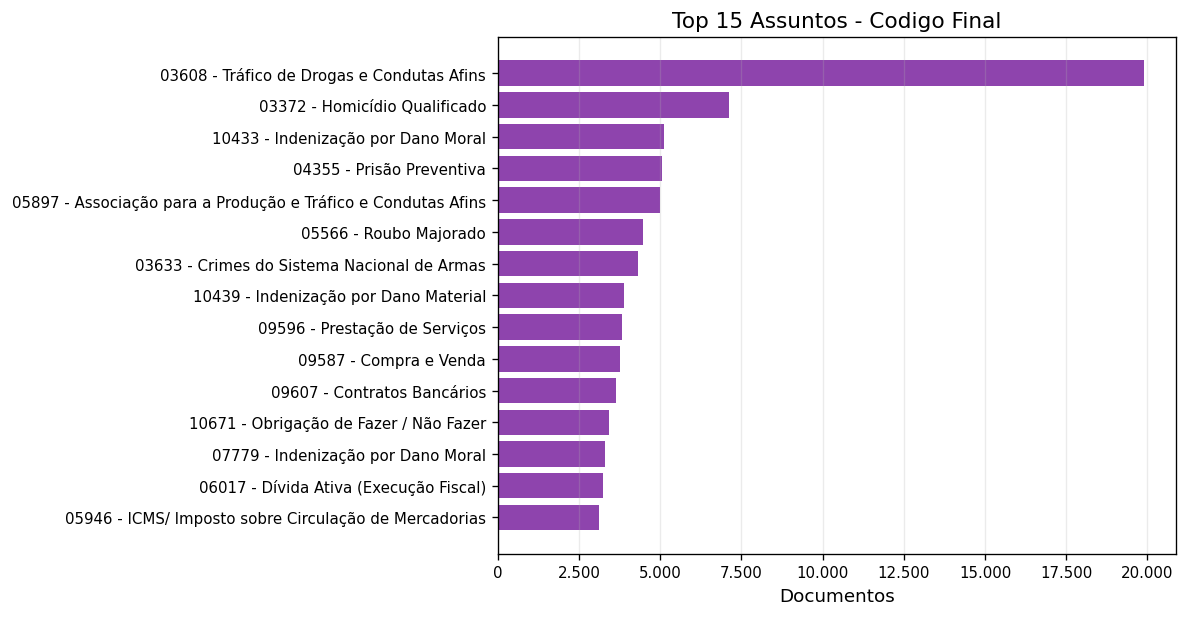

,codigo,assunto_exibicao,documentos,caminho_assuntos,instancias,n_instancias,tem_nome_lookup,nome_divergente_entre_instancias
0,03608,Tráfico de Drogas e Condutas Afins,19885,DIREITO PENAL > Crimes Previstos na Legislação Extravagante > Crimes de Tráfico Ilícito e Uso Indevido de Drogas > Tráfico de Drogas e Condutas Afins,Justiça Federal 1º Grau,1.0,True,False
1,03372,Homicídio Qualificado,7124,DIREITO PENAL > Crimes contra a vida > Homicídio Qualificado,Justiça Federal 1º Grau,1.0,True,False
2,10433,Indenização por Dano Moral,5118,DIREITO CIVIL > Responsabilidade Civil > Indenização por Dano Moral,Justiça Federal 1º Grau,1.0,True,False
3,04355,Prisão Preventiva,5054,DIREITO PROCESSUAL PENAL > Prisão Preventiva,Justiça Federal 1º Grau,1.0,True,False
4,05897,Associação para a Produção e Tráfico e Condutas Afins,4991,DIREITO PENAL > Crimes Previstos na Legislação Extravagante > Crimes de Tráfico Ilícito e Uso Indevido de Drogas > Associação para a Produção e Tráfico e Condutas Afins,Justiça Federal 1º Grau,1.0,True,False
5,05566,Roubo Majorado,4485,DIREITO PENAL > Crimes contra o Patrimônio > Roubo Majorado,Justiça Federal 1º Grau,1.0,True,False
6,03633,Crimes do Sistema Nacional de Armas,4306,DIREITO PENAL > Crimes Previstos na Legislação Extravagante > Crimes do Sistema Nacional de Armas,Justiça Federal 1º Grau,1.0,True,False
7,10439,Indenização por Dano Material,3881,DIREITO CIVIL > Responsabilidade Civil > Indenização por Dano Material,Justiça Federal 1º Grau,1.0,True,False
8,09596,Prestação de Serviços,3838,DIREITO CIVIL > Obrigações > Espécies de Contratos > Prestação de Serviços,Justiça Federal 1º Grau,1.0,True,False
9,09587,Compra e Venda,3755,DIREITO CIVIL > Obrigações > Espécies de Contratos > Compra e Venda,Justiça Federal 1º Grau,1.0,True,False


Tabela de assuntos rotulados salva em: /content/drive/MyDrive/Mestrado/2026/llms/data/reports/summaries/stj_top_assuntos_labeled.csv


In [31]:
def normalize_assunto_code(code: object) -> str | None:
    if pd.isna(code):
        return None
    text = str(code).strip()
    if not text:
        return None
    if re.fullmatch(r'\d+\.0', text):
        text = text[:-2]
    if re.fullmatch(r'\d+', text):
        return text.zfill(5)
    return text

def split_assunto_paths(value) -> list[str]:
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return []
    text = str(value).strip()
    if not text or text.lower() == 'nan':
        return []
    paths = re.split(r'\s*[;|,]\s*', text)
    normalized = []
    for path in paths:
        codes = [normalize_assunto_code(part) for part in str(path).split('.') if part]
        codes = [code for code in codes if code]
        if codes:
            normalized.append('.'.join(codes) + '.')
    return normalized

def final_assunto_code(path: str) -> str | None:
    codes = [part for part in str(path).split('.') if part]
    return codes[-1] if codes else None

def first_non_empty(values: pd.Series):
    cleaned = values.dropna().astype(str).str.strip()
    cleaned = cleaned[cleaned.ne('')]
    return cleaned.iloc[0] if not cleaned.empty else pd.NA

def join_unique(values: pd.Series) -> str:
    cleaned = values.dropna().astype(str).str.strip()
    cleaned = sorted(value for value in cleaned.unique() if value)
    return ' | '.join(cleaned)

def load_assuntos_lookup_from_candidates() -> pd.DataFrame:
    for path in ASSUNTOS_LOOKUP_CANDIDATES:
        if not path.exists():
            continue
        if path.suffix == '.parquet':
            loaded = pd.read_parquet(path)
        else:
            loaded = pd.read_csv(path, dtype={'codigo': 'string', 'codigo_pai': 'string'})
        print(f'Lookup recarregado para enriquecimento: {path} ({len(loaded):,} linhas)')
        return loaded
    return pd.DataFrame()

if 'assuntos_lookup' not in globals() or assuntos_lookup.empty:
    assuntos_lookup = load_assuntos_lookup_from_candidates()

def build_assuntos_lookup_by_codigo(lookup: pd.DataFrame) -> pd.DataFrame:
    if lookup.empty or 'codigo' not in lookup.columns:
        return pd.DataFrame(columns=['codigo', 'assunto', 'caminho_assuntos', 'instancias', 'n_instancias', 'assunto_variantes'])

    table = lookup.copy()
    table['codigo'] = table['codigo'].map(normalize_assunto_code)
    table = table.dropna(subset=['codigo'])

    if 'codigo_pai' in table.columns:
        table['codigo_pai'] = table['codigo_pai'].map(normalize_assunto_code)
    for col in ['assunto', 'caminho_assuntos', 'instancia']:
        if col not in table.columns:
            table[col] = pd.NA

    name_variants = (
        table.groupby('codigo')['assunto']
        .apply(lambda values: join_unique(values))
        .rename('assunto_variantes')
        .reset_index()
    )

    by_code = (
        table.groupby('codigo', as_index=False)
        .agg(
            assunto=('assunto', first_non_empty),
            codigo_pai=('codigo_pai', first_non_empty),
            caminho_assuntos=('caminho_assuntos', first_non_empty),
            instancias=('instancia', join_unique),
            n_instancias=('instancia', lambda values: values.dropna().astype(str).str.strip().replace('', pd.NA).dropna().nunique()),
        )
        .merge(name_variants, on='codigo', how='left')
    )
    by_code['nome_divergente_entre_instancias'] = by_code['assunto_variantes'].str.contains(r'\|', regex=True, na=False)
    return by_code

assuntos_lookup_codigo = build_assuntos_lookup_by_codigo(assuntos_lookup)
if not assuntos_lookup_codigo.empty:
    divergentes = int(assuntos_lookup_codigo['nome_divergente_entre_instancias'].sum())
    print(f'Lookup por codigo: {len(assuntos_lookup_codigo):,} codigos; nomes divergentes entre instancias: {divergentes:,}')

if 'assuntos' in df.columns:
    assunto_id_cols = [col for col in ['SeqDocumento', 'numeroProcesso', 'processo', 'arquivo_origem'] if col in df.columns]
    assuntos_long = (
        df[assunto_id_cols + ['assuntos']]
        .assign(assunto_path=lambda table: table['assuntos'].map(split_assunto_paths))
        .explode('assunto_path')
        .dropna(subset=['assunto_path'])
    )
    assuntos_long['assunto_final'] = assuntos_long['assunto_path'].map(final_assunto_code)

    top_assuntos = (
        assuntos_long['assunto_final']
        .value_counts()
        .rename_axis('codigo')
        .reset_index(name='documentos')
    )

    if not assuntos_lookup_codigo.empty:
        before_rows = len(top_assuntos)
        top_assuntos = top_assuntos.merge(
            assuntos_lookup_codigo,
            how='left',
            on='codigo',
        )
        if len(top_assuntos) != before_rows:
            print(f'Aviso: merge de assuntos alterou linhas de {before_rows:,} para {len(top_assuntos):,}.')
    else:
        top_assuntos['assunto'] = pd.NA
        top_assuntos['caminho_assuntos'] = pd.NA
        top_assuntos['instancias'] = pd.NA
        top_assuntos['n_instancias'] = 0
        top_assuntos['nome_divergente_entre_instancias'] = False

    top_assuntos['assunto_exibicao'] = top_assuntos['assunto'].fillna('(sem nome no lookup)')
    top_assuntos['rotulo_grafico'] = top_assuntos['codigo'] + ' - ' + top_assuntos['assunto_exibicao']
    top_assuntos['tem_nome_lookup'] = top_assuntos['assunto'].notna()

    matched = int(top_assuntos['tem_nome_lookup'].sum())
    print(f'Assuntos com nome no lookup: {matched:,} de {len(top_assuntos):,} codigos finais.')
    if not assuntos_lookup_codigo.empty:
        top_codes = top_assuntos['codigo'].head(10).tolist()
        missing_top = top_assuntos.loc[~top_assuntos['tem_nome_lookup'], 'codigo'].head(10).tolist()
        print(f'Top codigos analisados: {top_codes}')
        if missing_top:
            print(f'Codigos top sem match no lookup: {missing_top}')

    top_plot = top_assuntos.head(15).copy()
    plot_barh(
        pd.Series(top_plot['documentos'].values, index=top_plot['rotulo_grafico']),
        title='Top 15 Assuntos - Codigo Final',
        xlabel='Documentos',
        name='06_assuntos',
        color='#8E44AD',
    )

    display_cols = [
        'codigo',
        'assunto_exibicao',
        'documentos',
        'caminho_assuntos',
        'instancias',
        'n_instancias',
        'tem_nome_lookup',
        'nome_divergente_entre_instancias',
    ]
    plot_table(top_assuntos[display_cols], max_rows=30)

    output_path = REPORTS_DATA / 'stj_top_assuntos_labeled.csv'
    top_assuntos[display_cols].to_csv(output_path, index=False)
    print(f'Tabela de assuntos rotulados salva em: {output_path}')
else:
    print('Coluna assuntos nao encontrada.')

## 9. Síntese Executiva

In [32]:
print(f'Total de documentos: {len(df):,}')
print(f'Intervalo temporal: {df["dataPublicacao"].min() if "dataPublicacao" in df.columns else "N/A"} a {df["dataPublicacao"].max() if "dataPublicacao" in df.columns else "N/A"}')
print(f'Colunas: {df.shape[1]}')
print(f'Memoria: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')

figs = sorted(FIGURES_DATA.glob('*.png'))
print(f'\nGraficos gerados: {len(figs)}')
for fig in figs:
    print(f'  - {fig.name}')

Total de documentos: 193,979
Intervalo temporal: 2026-01-02 00:00:00 a 2026-04-17 00:00:00
Colunas: 15
Memoria: 148.6 MB

Graficos gerados: 6
  - 01_taxa_ausentes.png
  - 02_volume_diario.png
  - 03_tipo_documento.png
  - 04_ministros.png
  - 06_assuntos.png
  - stj_integras_tamanho_textos.png
